In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
from scipy.optimize import fsolve

In [4]:
df = pd.read_parquet("overnight_erdos_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7920 entries, 0 to 7919
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   n                 7920 non-null   int64  
 1   p                 7920 non-null   float64
 2   largest_fraction  7920 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 185.8 KB


In [9]:
fig = px.histogram(df, x = df['largest_fraction'])
fig.show()

In [21]:
pivot = df.pivot(index = 'n', columns = 'p', values = 'largest_fraction')
fig = go.Figure(data = go.Surface(
    z = pivot.values,
    x = df['p'].unique(),
    y = df['n'].unique(),
    colorscale = 'Blackbody',
    colorbar_title = 'Largest Fraction'
)
)

fig.update_layout(
    title = 'Largest Fraction of Connected Component in Erdos-Renyi Graphs',
    scene = dict(
        xaxis_title = 'Probability of Edge Creation (p)',
        xaxis_type = 'log', # Make sure probability is in log scale
        yaxis_title = 'Number of Nodes (n)',
        zaxis_title = 'Largest Fraction of Connected Component'
    ),
    width = 800,
    height = 800,
    margin = dict(l = 0, r = 0, b = 0, t = 0)
)

fig.show()

Running simulations...


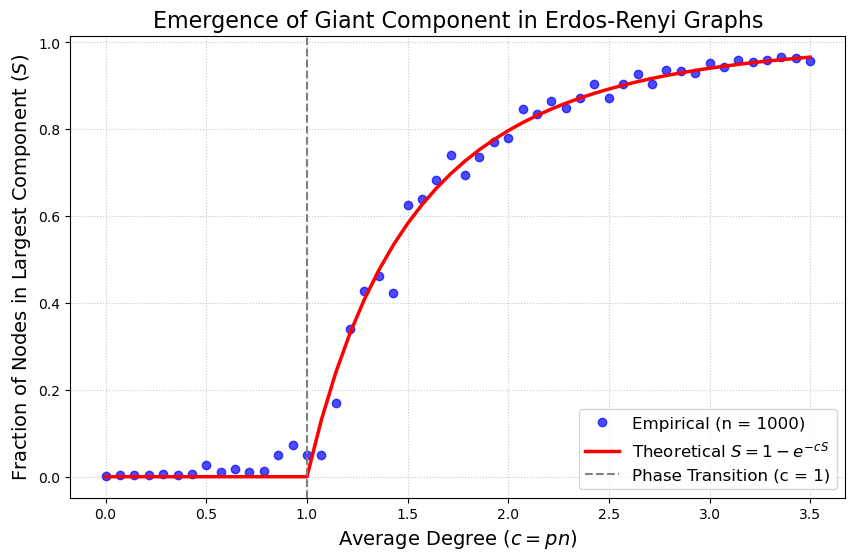

In [13]:
def theoretical_S(c):
    """Derived S value"""
    if c <= 1:
        return 0
    
    func = lambda S: S - 1 + np.exp(-c * S)

    S_solution = fsolve(func, 0.9)[0] # Use 0.9 as an initial guess for S
    return S_solution

n = 1000
"""1000 at roughly 3s, 2000 at roughly 11s, 10000 roughly at 2.5m"""
c_vals = np.linspace(0.0, 3.5, 50) # range of avg degrees to test
empirical_S = []
theoretical_S_vals = []

print("Running simulations...")
for c in c_vals:
    p = c / n

    G = nx.erdos_renyi_graph(n, p)

    largest_cc = max(nx.connected_components(G), key=len)

    empirical_S.append(len(largest_cc) / n)

    theoretical_S_vals.append(theoretical_S(c))

plt.figure(figsize=(10,6))
plt.plot(c_vals, empirical_S, 'o', label = f'Empirical (n = {n})', 
         markersize = 6, alpha = 0.7, color = 'blue')
plt.plot(c_vals, theoretical_S_vals, '-', label = 'Theoretical $S = 1 - e^{-cS}$', color = 'red', linewidth = 2.5)

#phase transitions
plt.axvline(x = 1, color = 'gray', linestyle = '--', label = 'Phase Transition (c = 1)')

plt.title('Emergence of Giant Component in Erdos-Renyi Graphs', fontsize = 16)
plt.xlabel('Average Degree ($c = pn$)', fontsize = 14)
plt.ylabel('Fraction of Nodes in Largest Component ($S$)', fontsize = 14)
plt.legend(fontsize = 12)
plt.grid(True, linestyle = ':', alpha = 0.7)

plt.show()